<a href="https://colab.research.google.com/github/moeenessa31-lgtm/Final-Project/blob/main/Iris_DBSCAN_PCA_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Iris Project: PCA + DBSCAN

This notebook follows the assignment requirements only. It is written in a simple way, with no custom functions and no loops in the main code.

Dataset used: `iris_full.csv`.

## 1. Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

## 2. Load the dataset

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Data preprocessing

The dataset contains 4 numeric features: sepal length, sepal width, petal length, and petal width.

Preprocessing steps:

1. Check missing values.
2. Use only numeric feature columns for clustering.
3. Fill missing values using the mean.
4. Standardize the features because DBSCAN depends on distance.

In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
X = df.drop('species', axis=1)

X = X.fillna(X.mean(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## 4. PCA implementation

PCA is used to reduce the 4 scaled features into 2 principal components. This makes visualization easier while keeping most of the information.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Variance explained by PC1:', pca.explained_variance_ratio_[0])
print('Variance explained by PC2:', pca.explained_variance_ratio_[1])
print('Total variance retained:', pca.explained_variance_ratio_.sum())

Variance explained by PC1: 0.7296244541329993
Variance explained by PC2: 0.22850761786701704
Total variance retained: 0.9581320720000163


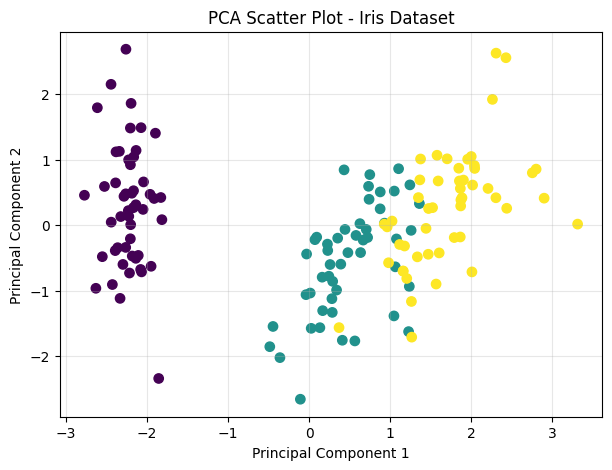

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['species'].astype('category').cat.codes, s=45)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot - Iris Dataset')
plt.grid(alpha=0.3)
plt.show()

## 5. Simple parameter tuning

I tried a small number of simple DBSCAN settings. The best simple setting was selected by looking for good silhouette score, low noise, and clear clusters.

No loops are used here to keep the code easy to explain.

In [ ]:
labels_o_08 = DBSCAN(eps=0.8, min_samples=3).fit_predict(X_scaled)
labels_o_10 = DBSCAN(eps=1.0, min_samples=3).fit_predict(X_scaled)
labels_o_12 = DBSCAN(eps=1.2, min_samples=3).fit_predict(X_scaled)
labels_o_14 = DBSCAN(eps=1.4, min_samples=3).fit_predict(X_scaled)

labels_p_08 = DBSCAN(eps=0.8, min_samples=3).fit_predict(X_pca)
labels_p_10 = DBSCAN(eps=1.0, min_samples=3).fit_predict(X_pca)
labels_p_12 = DBSCAN(eps=1.2, min_samples=3).fit_predict(X_pca)
labels_p_14 = DBSCAN(eps=1.4, min_samples=3).fit_predict(X_pca)

In [ ]:
tuning_table = pd.DataFrame({
    'data_used': ['Original', 'Original', 'Original', 'Original', 'PCA', 'PCA', 'PCA', 'PCA'],
    'eps': [0.8, 1.0, 1.2, 1.4, 0.8, 1.0, 1.2, 1.4],
    'min_samples': [3, 3, 3, 3, 3, 3, 3, 3],
    'clusters': [2, 2, 2, 2, 3, 2, 2, 2],
    'noise_points': [4, 1, 1, 0, 1, 1, 1, 0],
    'silhouette': [0.5217, 0.5046, 0.5046, 0.5818, 0.4425, 0.5381, 0.5381, 0.6145]
})

tuning_table

,data_used,eps,min_samples,clusters,noise_points,silhouette
0,Original,0.8,3,2,4,0.5217
1,Original,1.0,3,2,1,0.5046
2,Original,1.2,3,2,1,0.5046
3,Original,1.4,3,2,0,0.5818
4,PCA,0.8,3,3,1,0.4425
5,PCA,1.0,3,2,1,0.5381
6,PCA,1.2,3,2,1,0.5381
7,PCA,1.4,3,2,0,0.6145


## 6. DBSCAN on original scaled data

Final parameters used: `eps = 1.4`, `min_samples = 3`.

In [ ]:
dbscan_original = DBSCAN(eps=1.4, min_samples=3)
labels_original = dbscan_original.fit_predict(X_scaled)

clusters_original = len(set(labels_original)) - (1 if -1 in labels_original else 0)
noise_original = (labels_original == -1).sum()
silhouette_original = silhouette_score(X_scaled, labels_original)

print('Clusters:', clusters_original)
print('Noise points:', noise_original)
print('Silhouette score:', silhouette_original)

Clusters: 2
Noise points: 0
Silhouette score: 0.5817500491982808


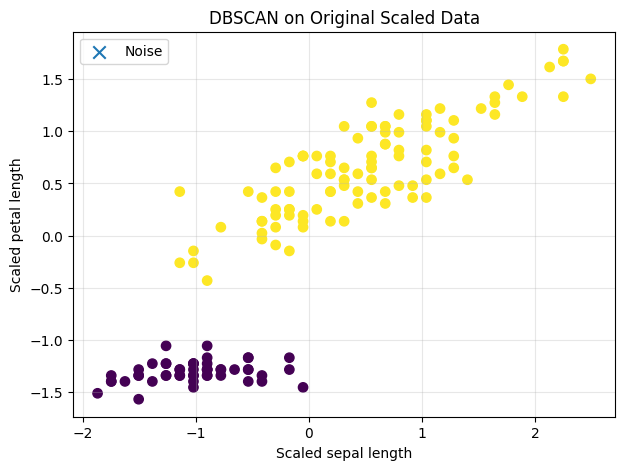

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:,0], X_scaled[:,2], c=labels_original, s=45)
plt.scatter(X_scaled[labels_original==-1,0], X_scaled[labels_original==-1,2], marker='x', s=80, label='Noise')
plt.xlabel('Scaled sepal length')
plt.ylabel('Scaled petal length')
plt.title('DBSCAN on Original Scaled Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. DBSCAN on PCA-reduced data

Final parameters used: `eps = 1.4`, `min_samples = 3`.

In [ ]:
dbscan_pca = DBSCAN(eps=1.4, min_samples=3)
labels_pca = dbscan_pca.fit_predict(X_pca)

clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
noise_pca = (labels_pca == -1).sum()
silhouette_pca = silhouette_score(X_pca, labels_pca)

print('Clusters:', clusters_pca)
print('Noise points:', noise_pca)
print('Silhouette score:', silhouette_pca)

Clusters: 2
Noise points: 0
Silhouette score: 0.614520203623045


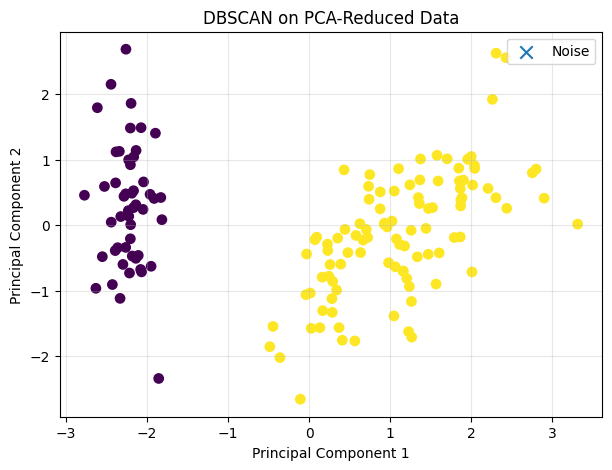

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, s=45)
plt.scatter(X_pca[labels_pca==-1,0], X_pca[labels_pca==-1,1], marker='x', s=80, label='Noise')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN on PCA-Reduced Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Evaluation and comparison

In [ ]:
comparison_table = pd.DataFrame({
    'method': ['DBSCAN without PCA', 'DBSCAN with PCA'],
    'eps': [1.4, 1.4],
    'min_samples': [3, 3],
    'clusters': [clusters_original, clusters_pca],
    'noise_points': [noise_original, noise_pca],
    'silhouette': [silhouette_original, silhouette_pca]
})

comparison_table

,method,eps,min_samples,clusters,noise_points,silhouette
0,DBSCAN without PCA,1.4,3,2,0,0.58175
1,DBSCAN with PCA,1.4,3,2,0,0.61452


## 9. Final discussion

The PCA version performed better because it produced a higher silhouette score. PCA reduced the data from 4 features to 2 components while keeping about 95.81% of the variance. This made the data easier to visualize and helped DBSCAN create clearer clusters.

DBSCAN found 2 main density-based clusters. This is acceptable because DBSCAN groups points based on density, not based on the real species labels. In the Iris dataset, versicolor and virginica overlap, so DBSCAN may merge them into one larger cluster.

Strengths of DBSCAN: it can find clusters without choosing the number of clusters before training, and it can detect noise.

Limitations of DBSCAN: it is sensitive to `eps` and `min_samples`, and it may merge close clusters when densities are similar.

## 10. Conclusion

PCA + DBSCAN worked well on the Iris dataset. The best simple result was DBSCAN on PCA data using `eps = 1.4` and `min_samples = 3`. This result had a better silhouette score than DBSCAN on the original scaled data.